In [24]:
if(system.file(package = "bagelR") != "")
    {
      remove.packages("bagelR")
    }
library("remotes")
install_github("grosed/bagel/bagelR",force=TRUE)

Removing package from ‘/home/grosed/DASS/R-packages’
(as ‘lib’ is unspecified)

Using GitHub PAT from the git credential store.




Running `R CMD build`...



* checking for file ‘/tmp/RtmpS9QjYO/remotes4da2c3dcbd5e6/grosed-bagel-f62c36a/bagelR/DESCRIPTION’ ... OK
* preparing ‘bagelR’:
* checking DESCRIPTION meta-information ... OK
* cleaning src
* installing the package to process help pages
* saving partial Rd database
* cleaning src
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘bagelR_1.5.0.tar.gz’


Installing package into ‘/home/grosed/DASS/R-packages’
(as ‘lib’ is unspecified)



In [2]:
packageVersion("bagelR")

[1] ‘1.5.0’

In [3]:
library(bagelR)


Attaching package: ‘bagelR’


The following objects are masked from ‘package:stats’:

    time, update




In [4]:
feature_vector <- function(t,tau)
{
  if(tau == 0)
  {
    M <- matrix(c(0),nc=1,nr=1)       
    M[1,1] <- 1
    return(M)
  }
  else
  {
    M <- matrix(c(0),nc=1,nr=2)       
    M[1,1] <- 1
    if(t > tau)
    {
      M[2,1] <- 1
    }
    return(M)
  }
}

In [5]:
prior <- function(t)
{
  mu1 <- 1;
  delta <- c(5,1)
  if(t == 1)
  {
    mu <- matrix(c(mu1),nc=1,nr=1)
    sigma <- delta[1]*diag(1)
    return(list("mu" = mu,"sigma" = sigma))
  }
  mu <- matrix(c(mu1,0),nc=1,nr=2)
  sigma <- diag(delta)
  return(list("mu" = mu,"sigma" = sigma))
}

In [6]:
transform <- function(tau)
{
	return(matrix(c(1,1),1,2,byrow=TRUE))
}

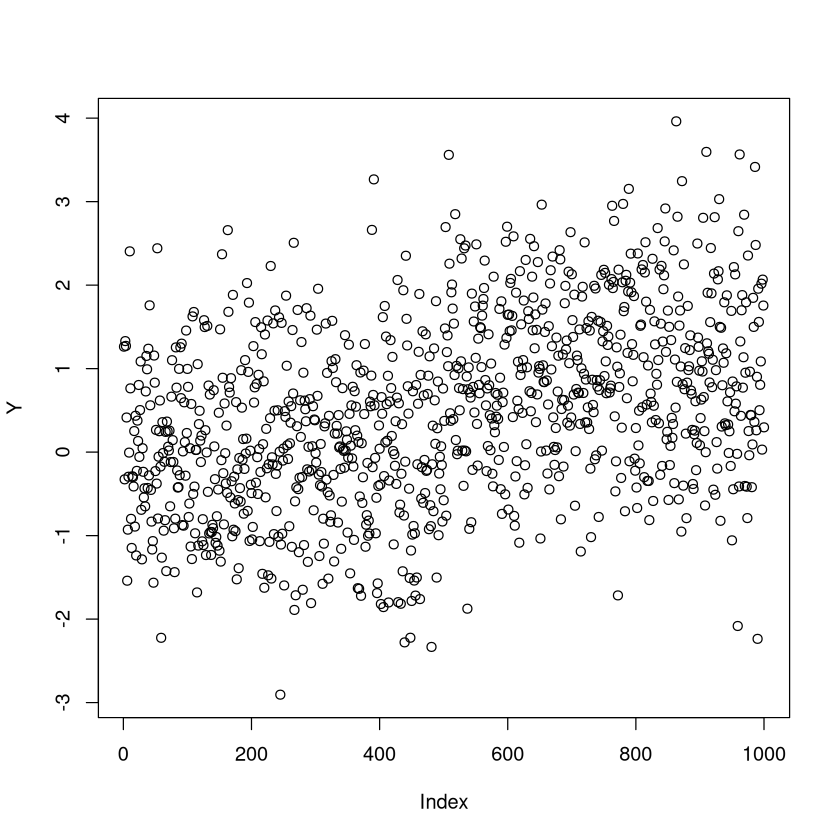

In [7]:
set.seed(0)
Y <- c(rnorm(500,0,1),rnorm(500,1,1))
plot(Y)

In [8]:
p <- 1.0;
p0 <- 0.9;
noise_sd <- 1.0;
max_particles <- 200
threshold <- 0.8

In [9]:
bagel_object <- sequential_bagel_kv_exact(feature_vector,prior,transform,p0,p,noise_sd,max_particles)

In [10]:
w0ts <- list()
for(y in Y[1:300])
{
   w0t <- update(bagel_object,y)
   w0ts <- append(w0ts,w0t)
   if(1.0 - w0t > threshold)
    {
	   break
    }
}

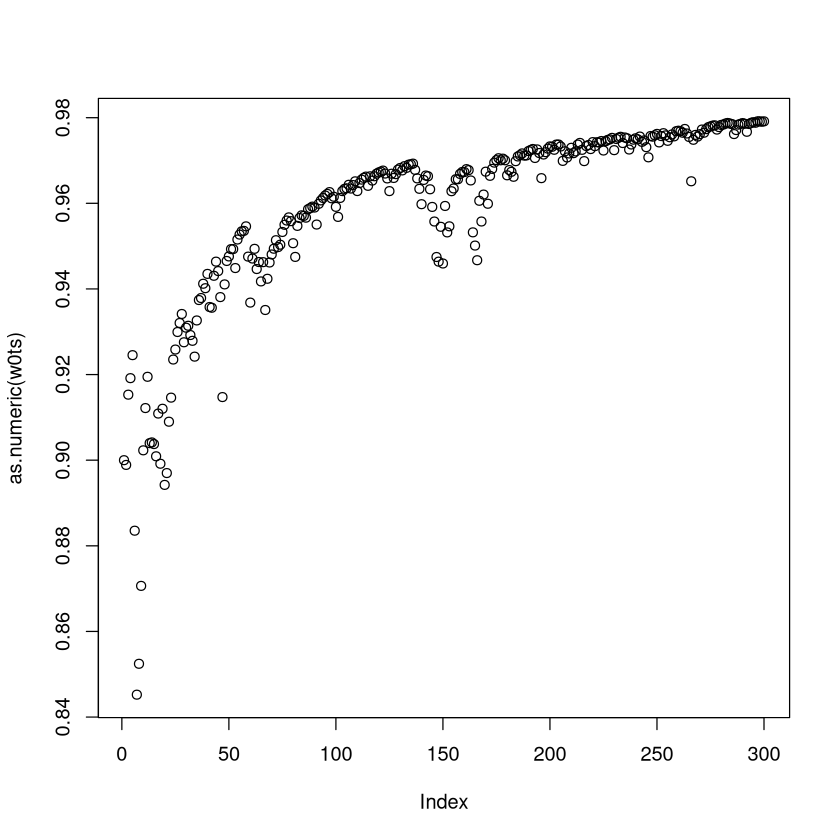

In [11]:
plot(as.numeric(w0ts))

In [12]:
for(y in Y[301:800])
{
   w0t <- update(bagel_object,y)
   w0ts <- append(w0ts,w0t)
   if(1.0 - w0t > threshold)
    {
	   break
    }
}

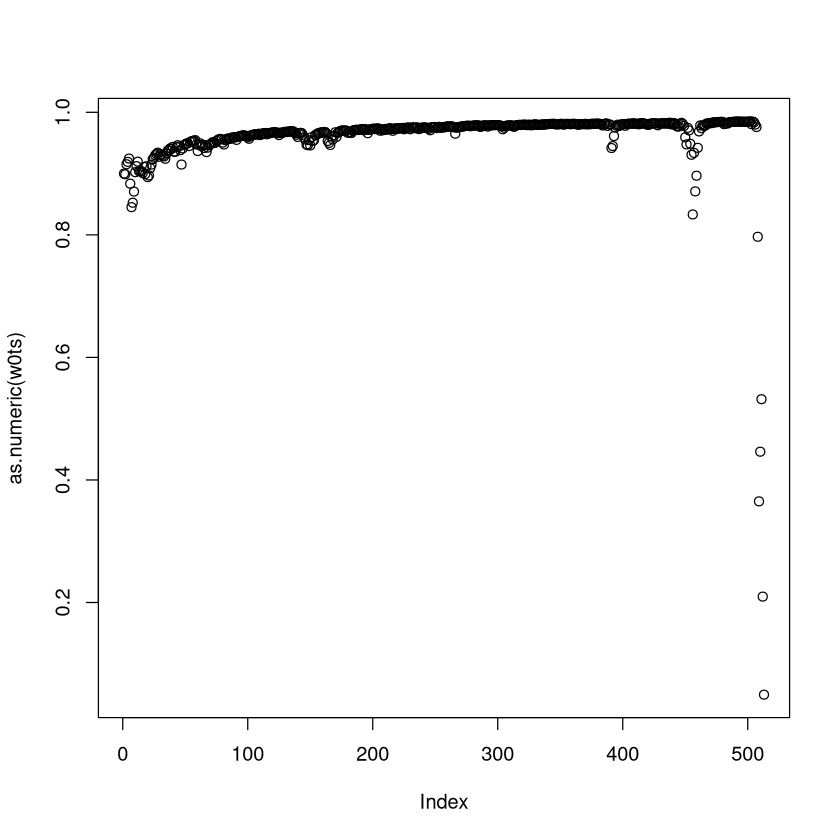

In [13]:
plot(as.numeric(w0ts))

In [14]:
time(bagel_object)

[1] 513

In [15]:
which.max(weights(bagel_object))

[1] 502

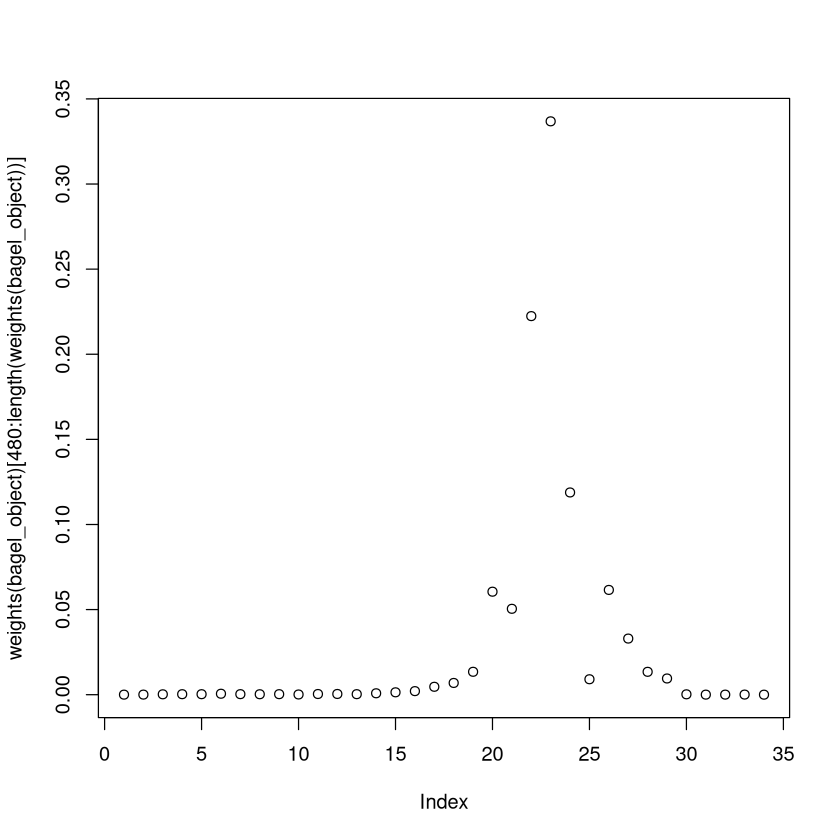

In [16]:
plot(weights(bagel_object)[480:length(weights(bagel_object))])

In [17]:
weights(bagel_object)

[1] 4.955916e-02 7.185226e-06 4.491311e-06 6.824857e-06 1.177668e-05
  [6] 1.147997e-05 4.159364e-06 2.872098e-06 2.534638e-06 2.386619e-06
 [11] 4.024379e-06 4.828124e-06 3.359560e-06 2.394466e-06 2.172890e-06
 [16] 1.999091e-06 1.847153e-06 1.834662e-06 1.665844e-06 1.668610e-06
 [21] 1.566594e-06 1.534179e-06 1.503548e-06 1.478129e-06 1.488681e-06
 [26] 1.457993e-06 1.467187e-06 1.579146e-06 1.455680e-06 1.334533e-06
 [31] 1.317535e-06 1.295637e-06 1.274467e-06 1.264389e-06 1.271689e-06
 [36] 1.227076e-06 1.216248e-06 1.242296e-06 1.211359e-06 1.265565e-06
 [41] 1.229693e-06 1.400924e-06 1.468319e-06 1.374923e-06 1.263831e-06
 [46] 1.169171e-06 1.108766e-06 1.079040e-06 1.069719e-06 1.086994e-06
 [51] 1.069728e-06 1.071812e-06 1.047411e-06 1.212019e-06 1.128624e-06
 [56] 1.116210e-06 1.123085e-06 1.158975e-06 1.136384e-06 1.036815e-06
 [61] 1.024715e-06 1.016989e-06 1.011506e-06 1.021784e-06 1.019029e-06
 [66] 1.045724e-06 1.028977e-06 1.132569e-06 1.098298e-06 1.076592e-06
 [71] 1.068048e-06 1.062158e-06 1.045197e-06 1.079943e-06 1.083257e-06
 [76] 1.043381e-06 1.002743e-06 9.954352e-07 9.946312e-07 1.028132e-06
 [81] 1.114791e-06 1.173470e-06 1.071065e-06 1.029339e-06 1.036038e-06
 [86] 1.055952e-06 1.079798e-06 1.009715e-06 1.022993e-06 9.667101e-07
 [91] 9.468575e-07 9.305073e-07 9.369383e-07 9.344563e-07 9.517878e-07
 [96] 9.354242e-07 9.309083e-07 9.349431e-07 9.172625e-07 9.147886e-07
[101] 9.181103e-07 9.293977e-07 9.128764e-07 9.096314e-07 9.074257e-07
[106] 9.301121e-07 9.147815e-07 9.429661e-07 9.102110e-07 9.146728e-07
[111] 9.066288e-07 9.022716e-07 8.964424e-07 8.947594e-07 8.932126e-07
[116] 8.995448e-07 8.874359e-07 9.054865e-07 8.972264e-07 8.862391e-07
[121] 8.830618e-07 8.825513e-07 8.795568e-07 8.904603e-07 9.042387e-07
[126] 9.330199e-07 8.862600e-07 8.593117e-07 8.552243e-07 8.739658e-07
[131] 8.730355e-07 8.570063e-07 8.603675e-07 8.507471e-07 8.628887e-07
[136] 8.512542e-07 8.635473e-07 8.971602e-07 9.362712e-07 9.830201e-07
[141] 1.043638e-06 9.969458e-07 9.927558e-07 1.011306e-06 1.087082e-06
[146] 1.177749e-06 1.260185e-06 1.419541e-06 1.495094e-06 1.416129e-06
[151] 1.633208e-06 1.382202e-06 1.601389e-06 1.622188e-06 1.235721e-06
[156] 1.141686e-06 1.167050e-06 1.267451e-06 1.199451e-06 1.201899e-06
[161] 1.247548e-06 1.212186e-06 1.271734e-06 1.013609e-06 9.103943e-07
[166] 8.721759e-07 8.429138e-07 8.614574e-07 8.328731e-07 8.408088e-07
[171] 8.683915e-07 8.176048e-07 8.315383e-07 8.377178e-07 8.518111e-07
[176] 8.797015e-07 8.586159e-07 9.237316e-07 9.364830e-07 9.706959e-07
[181] 1.066646e-06 1.072347e-06 1.107004e-06 1.156263e-06 1.082689e-06
[186] 1.051738e-06 1.056921e-06 1.047594e-06 1.098845e-06 1.118247e-06
[191] 1.028509e-06 1.030793e-06 1.017912e-06 8.648679e-07 9.128899e-07
[196] 8.562601e-07 7.815078e-07 8.156046e-07 8.154316e-07 8.275452e-07
[201] 8.455108e-07 8.918778e-07 9.401406e-07 8.859354e-07 8.649198e-07
[206] 8.410497e-07 7.990899e-07 8.046133e-07 7.952888e-07 7.965179e-07
[211] 8.060456e-07 7.860878e-07 7.858104e-07 8.133125e-07 8.224293e-07
[216] 7.898668e-07 7.782116e-07 7.986088e-07 7.969399e-07 7.776382e-07
[221] 8.234451e-07 7.778753e-07 7.947054e-07 7.881935e-07 7.939825e-07
[226] 7.635255e-07 7.949708e-07 7.995136e-07 8.369806e-07 8.201057e-07
[231] 7.617528e-07 8.020255e-07 8.048388e-07 8.098886e-07 7.865598e-07
[236] 7.991946e-07 7.920604e-07 7.891543e-07 7.906885e-07 7.945805e-07
[241] 7.947634e-07 7.963322e-07 8.056740e-07 7.855320e-07 7.860929e-07
[246] 8.644977e-07 9.181730e-07 8.532529e-07 8.871322e-07 8.909749e-07
[251] 8.907444e-07 9.273830e-07 9.168248e-07 9.081588e-07 8.922880e-07
[256] 9.027708e-07 9.047937e-07 9.032586e-07 9.189224e-07 8.927297e-07
[261] 8.963345e-07 9.065020e-07 9.210895e-07 9.052644e-07 9.408698e-07
[266] 9.619985e-07 1.084211e-06 9.856085e-07 9.672886e-07 9.259705e-07
[271] 9.214149e-07 9.257642e-07 9.653935e-07 9.563484e-07 9.380966e-07
[276] 9.354920e-07 9.413508e-07 9.433046e-07 9.676202e-07 9.631728e-07
[281] 9.445522e-07 9.57544

In [18]:
active_weights(bagel_object)

[1] 4.955916e-02 3.763754e-04 1.243641e-06 1.142241e-06 1.165978e-06
  [6] 1.114638e-06 1.144676e-06 1.253712e-06 1.224606e-06 1.270432e-06
 [11] 1.351814e-06 1.438883e-06 1.331185e-06 1.206777e-06 1.146171e-06
 [16] 1.166470e-06 1.264925e-06 1.252077e-06 1.177142e-06 1.131761e-06
 [21] 1.118899e-06 1.111335e-06 1.160902e-06 1.139406e-06 1.140214e-06
 [26] 1.140383e-06 1.155785e-06 1.237165e-06 1.290153e-06 1.234509e-06
 [31] 1.236792e-06 1.240939e-06 1.260732e-06 1.169025e-06 1.172375e-06
 [36] 1.162155e-06 1.158014e-06 1.223752e-06 1.233808e-06 1.156725e-06
 [41] 1.136828e-06 1.228939e-06 1.228863e-06 1.196560e-06 1.206457e-06
 [46] 1.164170e-06 1.178680e-06 1.253902e-06 1.208563e-06 1.197134e-06
 [51] 1.170279e-06 1.123903e-06 1.119676e-06 1.208589e-06 1.206348e-06
 [56] 1.337140e-06 1.396247e-06 1.314223e-06 1.500837e-06 1.497602e-06
 [61] 1.588255e-06 1.644049e-06 1.519660e-06 1.474000e-06 1.348236e-06
 [66] 1.474609e-06 1.597905e-06 1.727716e-06 1.764393e-06 1.977524e-06
 [71] 2.194732e-06 2.506677e-06 2.345970e-06 2.216300e-06 2.012048e-06
 [76] 1.559725e-06 1.596580e-06 1.517768e-06 1.235541e-06 1.210584e-06
 [81] 1.220120e-06 1.287031e-06 1.336621e-06 1.518067e-06 1.763681e-06
 [86] 1.855496e-06 1.812717e-06 1.822739e-06 1.918325e-06 2.409397e-06
 [91] 2.243633e-06 2.146893e-06 1.814243e-06 2.264284e-06 2.378212e-06
 [96] 1.951601e-06 1.948049e-06 1.708618e-06 1.636367e-06 1.631599e-06
[101] 1.525661e-06 1.809501e-06 1.894937e-06 1.799104e-06 1.605025e-06
[106] 1.522560e-06 1.513318e-06 1.412093e-06 1.421541e-06 1.547436e-06
[111] 1.564476e-06 1.599940e-06 1.567800e-06 1.632601e-06 1.563681e-06
[116] 1.384216e-06 1.561163e-06 1.510472e-06 1.608603e-06 1.714843e-06
[121] 2.098274e-06 2.196545e-06 2.139597e-06 2.625728e-06 2.072390e-06
[126] 2.310356e-06 3.302552e-06 3.441238e-06 2.441792e-06 2.031890e-06
[131] 1.803589e-06 1.701891e-06 1.658723e-06 1.738845e-06 2.048075e-06
[136] 2.805684e-06 3.488271e-06 5.073130e-06 6.535019e-06 5.728681e-06
[141] 7.305254e-06 1.137958e-05 1.583473e-05 2.906754e-05 2.366683e-05
[146] 4.260688e-05 4.844828e-05 4.213907e-05 2.939631e-05 1.665787e-05
[151] 3.236653e-05 2.505375e-05 3.292227e-05 3.813473e-05 2.422139e-05
[156] 3.267196e-05 2.749117e-05 3.088280e-05 4.080379e-05 2.578670e-05
[161] 3.060188e-05 3.649244e-05 3.033385e-05 2.326826e-05 3.695959e-05
[166] 2.558191e-05 3.672100e-05 6.122856e-05 2.334422e-04 3.021372e-04
[171] 3.021862e-04 5.678202e-04 3.240850e-04 2.723273e-04 3.153978e-04
[176] 1.303835e-04 4.082756e-04 4.314306e-04 3.137734e-04 8.341677e-04
[181] 1.402367e-03 2.101769e-03 4.651035e-03 6.906250e-03 1.345975e-02
[186] 6.051434e-02 5.046412e-02 2.224059e-01 3.368322e-01 1.188114e-01
[191] 9.079468e-03 6.155432e-02 3.297376e-02 1.344428e-02 9.529690e-03
[196] 2.251450e-04 4.134135e-05 4.884546e-05 7.406292e-05 2.013335e-05

In [19]:
ratios(bagel_object)

[[1]]
[1] 1

[[2]]
  [1] 0.019090585 0.011933062 0.018133112 0.031289727 0.030501392 0.011051105
  [7] 0.007630940 0.006734334 0.006341059 0.010692462 0.012827948 0.008926088
 [13] 0.006361909 0.005773199 0.005311428 0.004907740 0.004874554 0.004426017
 [19] 0.004433366 0.004162319 0.004076195 0.003994809 0.003927274 0.003955309
 [25] 0.003873773 0.003898202 0.004195667 0.003867627 0.003545749 0.003500586
 [31] 0.003442405 0.003386159 0.003359381 0.003378778 0.003260246 0.003231475
 [37] 0.003300682 0.003218485 0.003362506 0.003267198 0.003722145 0.003901210
 [43] 0.003653062 0.003357900 0.003106397 0.002945903 0.002866925 0.002842159
 [49] 0.002888058 0.002842185 0.002847722 0.002782890 0.003220240 0.002998667
 [55] 0.002965682 0.002983950 0.003079306 0.003019284 0.002754737 0.002722587
 [61] 0.002702061 0.002687493 0.002714801 0.002707480 0.002778407 0.002733911
 [67] 0.003009148 0.002918092 0.002860420 0.002837719 0.002822071 0.002777007
 [73] 0.002869324 0.002878128 0.002772181 0.002664210 0.002644794 0.002642657
 [79] 0.002731666 0.002961913 0.003117819 0.002845735 0.002734873 0.002752673
 [85] 0.002805581 0.002868938 0.002682733 0.002718012 0.002568473 0.002515726
 [91] 0.002472285 0.002489372 0.002482777 0.002528826 0.002485349 0.002473351
 [97] 0.002484071 0.002437095 0.002430522 0.002439347 0.002469337 0.002425441
[103] 0.002416820 0.002410959 0.002471235 0.002430503 0.002505387 0.002418360
[109] 0.002430214 0.002408842 0.002397265 0.002381777 0.002377306 0.002373196
[115] 0.002390020 0.002357848 0.002405807 0.002383861 0.002354668 0.002346226
[121] 0.002344870 0.002336914 0.002365884 0.002402491 0.002478961 0.002354724
[127] 0.002283124 0.002272264 0.002322059 0.002319587 0.002276999 0.002285929
[133] 0.002260369 0.002292628 0.002261716 0.002294378 0.002383685 0.002487599
[139] 0.002611808 0.002772865 0.002648807 0.002637675 0.002686962 0.002888292
[145] 0.003129187 0.003348212 0.003771609 0.003972348 0.003762543 0.004339306
[151] 0.003672403 0.004254766 0.004310026 0.003283214 0.003033370 0.003100762
[157] 0.003367518 0.003186849 0.003193352 0.003314638 0.003220684 0.003378898
[163] 0.002693079 0.002418847 0.002317303 0.002239556 0.002288825 0.002212879
[169] 0.002233963 0.002307248 0.002172312 0.002209332 0.002225751 0.002263195
[175] 0.002337298 0.002281275 0.002454283 0.002488162 0.002579063 0.002833995
[181] 0.002849142 0.002941223 0.003072099 0.002876620 0.002794385 0.002808156
[187] 0.002783374 0.002919544 0.002971094 0.002732667 0.002738736 0.002704513
[193] 0.002297886 0.002425477 0.002275016 0.002076405 0.002166998 0.002166538
[199] 0.002198723 0.002246456 0.002369650 0.002497880 0.002353861 0.002298024
[205] 0.002234603 0.002123120 0.002137795 0.002113020 0.002116286 0.002141600
[211] 0.002088574 0.002087837 0.002160908 0.002185130 0.002098614 0.002067647
[217] 0.002121841 0.002117407 0.002066124 0.002187829 0.002066754 0.002111470
[223] 0.002094168 0.002109549 0.002028628 0.002112175 0.002124245 0.002223792
[229] 0.002178957 0.002023918 0.002130919 0.002138394 0.002151811 0.002089828
[235] 0.002123398 0.002104443 0.002096721 0.002100798 0.002111138 0.002111624
[241] 0.002115792 0.002140613 0.002087097 0.002088587 0.002296903 0.002439514
[247] 0.002267026 0.002357041 0.002367251 0.002366638 0.002463984 0.002435932
[253] 0.002412907 0.002370739 0.002398591 0.002403966 0.002399887 0.002441505
[259] 0.002371913 0.002381491 0.002408505 0.002447263 0.002405217 0.002499818
[265] 0.002555955 0.002880663 0.002618685 0.002570010 0.002460231 0.002448127
[271] 0.002459683 0.002564975 0.002540943 0.002492449 0.002485529 0.002501096
[277] 0.002506287 0.002570891 0.002559075 0.002509601 0.002544120 0.002477584
[283] 0.002515164 0.002551392 0.002585487 0.002753881 0.002733832 0.002621864
[289] 0.002626688 0.002613576 0.002657497 0.002794483 0.002627699 0.002614505
[295] 0.002621560 0.002669820 0.002615673 0.002648869 0.002689498 0.002690771
[301] 0.002680907 0.002849618 0.002934664 0.003173863 0.003133452 0.002990253
[30

In [20]:
weights_tau_zero(bagel_object)

[1] 0.04955916

In [21]:
taus(bagel_object)

[1]   0 314 315 316 317 318 319 320 321 322 323 324 325 326 327 328 329 330
 [19] 331 332 333 334 335 336 337 338 339 340 341 342 343 344 345 346 347 348
 [37] 349 350 351 352 353 354 355 356 357 358 359 360 361 362 363 364 365 366
 [55] 367 368 369 370 371 372 373 374 375 376 377 378 379 380 381 382 383 384
 [73] 385 386 387 388 389 390 391 392 393 394 395 396 397 398 399 400 401 402
 [91] 403 404 405 406 407 408 409 410 411 412 413 414 415 416 417 418 419 420
[109] 421 422 423 424 425 426 427 428 429 430 431 432 433 434 435 436 437 438
[127] 439 440 441 442 443 444 445 446 447 448 449 450 451 452 453 454 455 456
[145] 457 458 459 460 461 462 463 464 465 466 467 468 469 470 471 472 473 474
[163] 475 476 477 478 479 480 481 482 483 484 485 486 487 488 489 490 491 492
[181] 493 494 495 496 497 498 499 500 501 502 503 504 505 506 507 508 509 510
[199] 511 512

In [22]:
time(bagel_object)

[1] 513

In [23]:
max_particles(bagel_object)

[1] 200